In [1]:
import os
import mudata as mu
import pertpy as pt
import scanpy as sc
import pandas as pd
import mudata as mu
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

milo = pt.tl.Milo()

from pertpy.tools import Milo

### DA testing with GLM (Age model)

In [2]:
mdata_cd8_age = mu.read("/scratch/user/s4575250/BIOX7014_Thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_milo_nhoods_built.h5mu")

In [3]:
mdata_cd8_age

MuData object with n_obs × n_vars = 265696 × 52345
  2 modalities
    rna:	265568 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Batch', 'Age_group', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'Batch_colors', 'Sex_colors', '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'neighbors', 'nhood_neighbors_key', 'pica_cell_type_complete_01_gdT_corrected_colors', 'pool_id_colors', 'sequencing_batch_colors', 'umap'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 13739
      obs:	'Age_years', 'Sex', 'Batch', 'Age', 'Age_group'
      var:	'ind

In [4]:
milo.da_nhoods(
    mdata_cd8_age,
    design="~ Batch + Sex + Age_years",
    model_contrasts="Age_years",   
    solver="pydeseq2"                  
)

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/pydeseq2/dds.py:539: UserWarning: Every gene contains at least one zero, cannot compute log geometric means. Switching to iterative mode.
  self.fit_size_factors(
Fitting dispersions...
... done in 3.05 seconds.

Fitting MAP dispersions...
... done in 3.26 seconds.

/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Fitting dispersions...
... done in 5.49 seconds.

Fitting MAP dispersions...
... done in 5.38 seconds.

Fitting dispersions...
... done in 6.23 seconds.

Fitting MAP dispersions...
... done in 5.17 seconds.

Fitting dispersions...
... done in 4.29 seconds.

Fitting MAP dispersions...
... done in 3.90 seconds.

Fitting dispersions...
... done in 4.82 seconds.

Fitting M

Log2 fold change & Wald test p-value: Age_years 17.03 vs 0.05
       baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
0      3.695683       -0.612617  0.517210 -1.184465  0.236229  0.331359
1      3.243048       -0.130623  0.654553 -0.199560  0.841825  0.881993
2      7.897237       -0.728721  0.440725 -1.653461  0.098237  0.162313
3      1.929724       -0.512640  0.485892 -1.055051  0.291402  0.392161
4      3.789357        1.950252  0.556348  3.505454  0.000456  0.001698
...         ...             ...       ...       ...       ...       ...
13734  4.077080        1.469387  0.475583  3.089653  0.002004  0.006054
13735  3.581736       -0.397940  0.752269 -0.528986  0.596815  0.685980
13736  4.494113       -0.264892  0.551776 -0.480072  0.631176  0.714546
13737  3.109771       -0.277205  0.455256 -0.608900  0.542591  0.638241
13738  4.271211       -0.895307  0.476259 -1.879875  0.060125  0.108392

[13739 rows x 6 columns]


... done in 1.67 seconds.



In [6]:
mdata_cd8_age["milo"].var.columns.tolist()

['index_cell',
 'kth_distance',
 'logCPM',
 'logFC',
 'PValue',
 'FDR',
 'SpatialFDR']

In [7]:
mdata_cd8_age["milo"].uns

{'sample_col': 'pica_id'}

In [8]:
# Check what model_contrasts was stored
print(mdata_cd8_age["milo"].uns.get("model_contrasts"))
print(mdata_cd8_age["milo"].uns.get("contrast"))

None
None


In [9]:
# Check what contrast was actually used
print("Model uns:", mdata_cd8_age["milo"].uns)

# Check the logFC values
print("\nlogFC head:")
print(mdata_cd8_age["milo"].var["logFC"].head(10))

# Check range makes sense
print("\nlogFC range:")
print(mdata_cd8_age["milo"].var["logFC"].describe())

# Check p-values are not all 1
print("\nPValue head:")
print(mdata_cd8_age["milo"].var["PValue"].head(10))

Model uns: {'sample_col': 'pica_id'}

logFC head:
0   -0.612617
1   -0.130623
2   -0.728721
3   -0.512640
4    1.950252
5   -1.918207
6    1.120164
7    1.324776
8   -0.942090
9   -1.189622
Name: logFC, dtype: float64

logFC range:
count    13739.000000
mean        -0.233391
std          1.682738
min         -6.670274
25%         -1.363135
50%         -0.170386
75%          0.921518
max          6.063813
Name: logFC, dtype: float64

PValue head:
0    2.362292e-01
1    8.418247e-01
2    9.823704e-02
3    2.914020e-01
4    4.558295e-04
5    3.493895e-07
6    1.598974e-02
7    9.584066e-02
8    9.630807e-02
9    2.469485e-02
Name: PValue, dtype: float64


In [10]:
mdata_cd8_age["milo"].obs["pica_id"] = mdata_cd8_age["milo"].obs.index

In [11]:
mdata_cd8_age["milo"].obs["Age_group"] = pd.cut(
    mdata_cd8_age["milo"].obs["Age_years"],
    bins=[0,3,6,10,14,18],
    labels=["0-3","4-6","7-10","11-14","15-18"],
    include_lowest=True
)

mdata_cd8_age["milo"].obs["Age_group"] = pd.Categorical(
    mdata_cd8_age["milo"].obs["Age_group"],
    categories=["0-3","4-6","7-10","11-14","15-18"],
    ordered=True
)

In [12]:
mdata_cd8_age["milo"].obs

,Age_years,Batch,Sex,pica_id,Age_group
PICA0001,2.09,Batch01,Male,PICA0001,0-3
PICA0002,15.09,Batch01,Male,PICA0002,15-18
PICA0003,0.83,Batch01,Male,PICA0003,0-3
PICA0004,1.46,Batch01,Male,PICA0004,0-3
PICA0005,9.30,Batch01,Male,PICA0005,7-10
...,...,...,...,...,...
PICA0164,2.15,Batch07,Male,PICA0164,0-3
PICA0166,0.62,Batch07,Male,PICA0166,0-3
PICA0168,16.20,Batch07,Male,PICA0168,15-18
PICA0169,2.72,Batch07,Male,PICA0169,0-3


In [13]:
mdata_cd8_age["milo"].var

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR
0,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.265390,3.695683,-0.612617,0.236229,0.331359,0.331846
1,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.257657,3.243048,-0.130623,0.841825,0.881993,0.882227
2,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.009837,7.897237,-0.728721,0.098237,0.162313,0.162723
3,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.541760,1.929724,-0.512640,0.291402,0.392161,0.392736
4,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.219984,3.789357,1.950252,0.000456,0.001698,0.001704
...,...,...,...,...,...,...,...
13734,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.201525,4.077080,1.469387,0.002004,0.006054,0.006076
13735,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.723792,3.581736,-0.397940,0.596815,0.685980,0.686256
13736,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.386278,4.494113,-0.264892,0.631176,0.714546,0.714859
13737,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.204317,3.109771,-0.277205,0.542591,0.638241,0.638533


In [14]:
mdata_cd8_age.write_h5mu("/scratch/user/s4575250/BIOX7014_Thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_age_combined_annot_with_age_nhood.h5mu")

In [15]:
mdata_cd8_age["milo"].var.to_csv("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/03_milo/cd8_milo_age_results.csv")

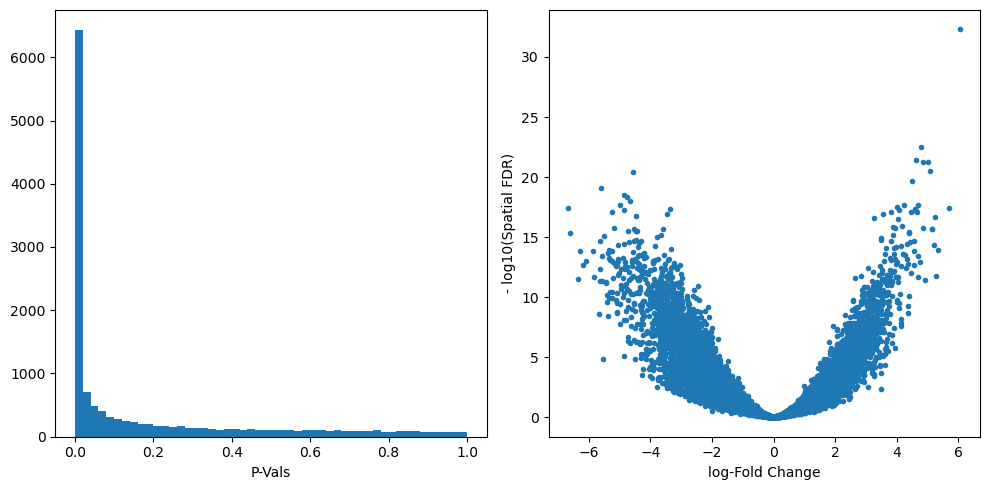

In [16]:
# QC
old_figsize = plt.rcParams["figure.figsize"]
plt.rcParams["figure.figsize"] = [10, 5]
plt.subplot(1, 2, 1)
plt.hist(mdata_cd8_age["milo"].var.PValue, bins=50)
plt.xlabel("P-Vals")
plt.subplot(1, 2, 2)
plt.plot(mdata_cd8_age["milo"].var.logFC, -np.log10(mdata_cd8_age["milo"].var.SpatialFDR), ".")
plt.xlabel("log-Fold Change")
plt.ylabel("- log10(Spatial FDR)")
plt.tight_layout()
plt.rcParams["figure.figsize"] = old_figsize

<Axes: xlabel='Age_group'>

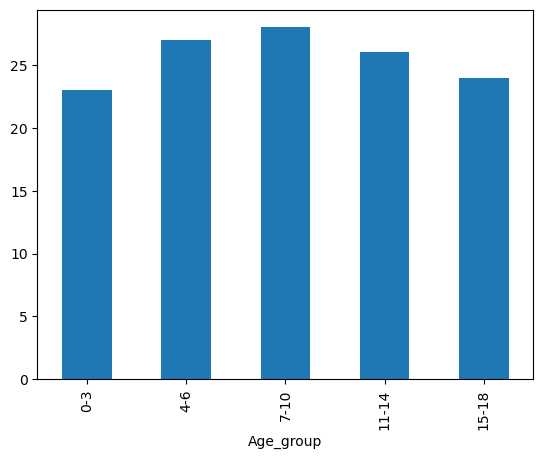

In [17]:
mdata_cd8_age["milo"].obs["Age_group"].value_counts().sort_index().plot.bar()

### Visualize embedding

In [18]:
milo.build_nhood_graph(mdata_cd8_age)

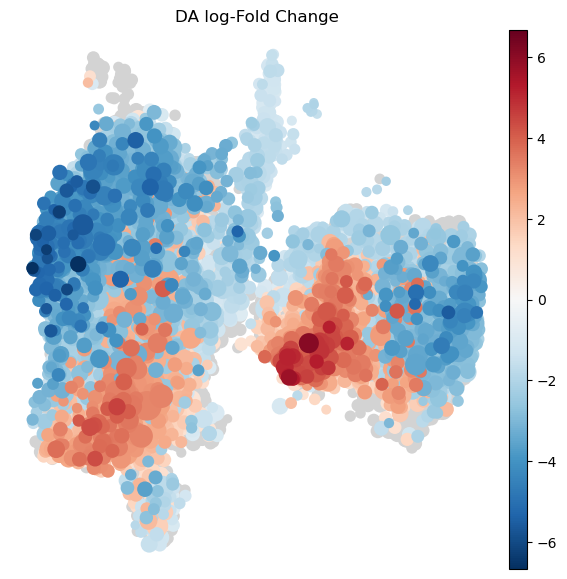

In [19]:
plt.rcParams["figure.figsize"] = [7, 7]
milo.plot_nhood_graph(
    mdata_cd8_age,
    alpha=0.1,  # SpatialFDR level (1%)
    min_size=1,  # Size of smallest dot
)

### Visualize by cell type

In [20]:
milo.annotate_nhoods(mdata_cd8_age, anno_col="pica_cell_type_complete_01_gdT_corrected")


Text(0.5, 0, 'celltype fraction')

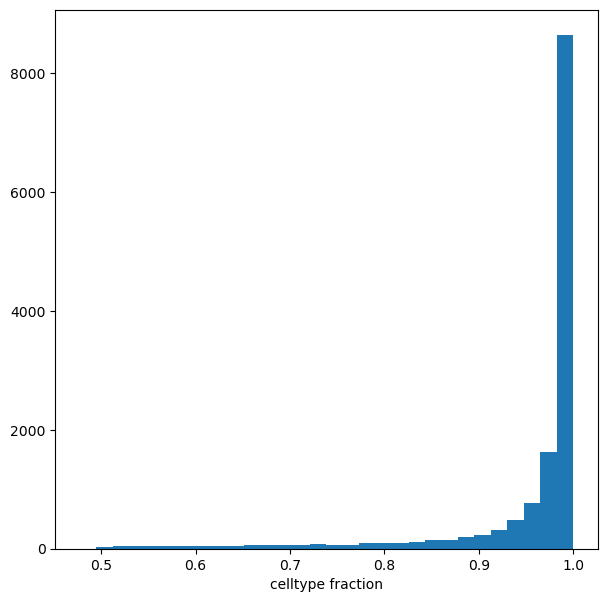

In [21]:
plt.hist(mdata_cd8_age["milo"].var["nhood_annotation_frac"], bins=30)
plt.xlabel("celltype fraction")

In [22]:
mdata_cd8_age["milo"].var["nhood_annotation"] = mdata_cd8_age["milo"].var["nhood_annotation"].cat.add_categories("Mixed")
mdata_cd8_age["milo"].var.loc[mdata_cd8_age["milo"].var["nhood_annotation_frac"] < 0.6, "nhood_annotation"] = "Mixed"

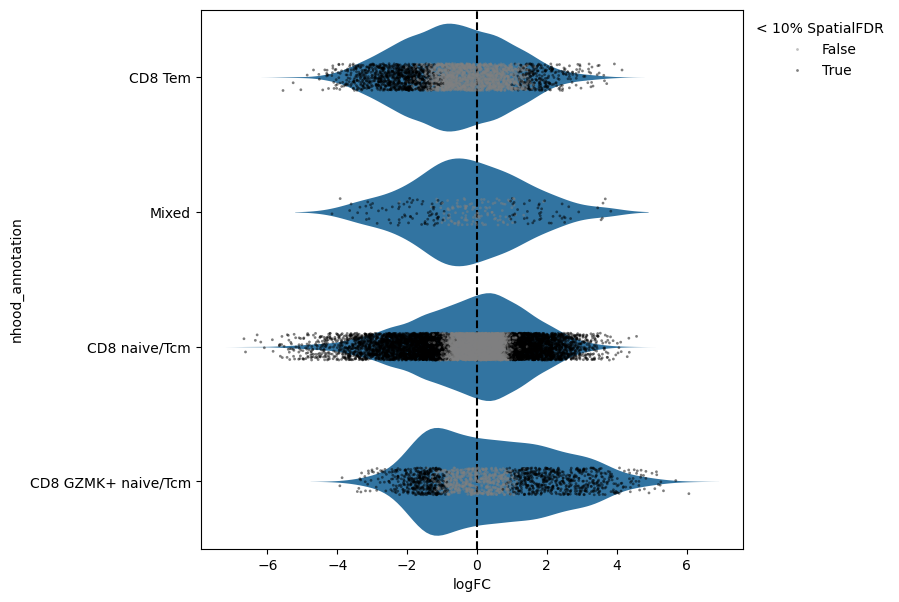

In [23]:
milo.plot_da_beeswarm(mdata_cd8_age, alpha=0.1)

In [24]:
sig_nhoods_cd8_age = mdata_cd8_age["milo"].var.query(
    "SpatialFDR < 0.1"
).copy()

sig_nhoods_cd8_age.sort_values("logFC", ascending=False).head()

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR,Nhood_size,nhood_annotation,nhood_annotation_frac
12075,20241106_WGS_20241106_sc_PICA0033-PICA0069_Poo...,3.332197,5.870527,6.063813,3.786724e-37,5.202580e-33,5.073253e-33,837.0,CD8 GZMK+ naive/Tcm,0.988053
4605,20250114_WGS_20241218_sc_PICA0071-PICA0097_Poo...,3.576371,3.251513,5.688078,5.278409e-21,4.045827e-18,4.065532e-18,561.0,CD8 GZMK+ naive/Tcm,0.998217
1810,20250114_WGS_20241218_sc_PICA0071-PICA0097_Poo...,3.810735,2.559272,5.336461,5.907859e-17,1.068001e-14,1.076723e-14,381.0,CD8 GZMK+ naive/Tcm,1.000000
2846,20250114_WGS_20241218_sc_PICA0071-PICA0097_Poo...,3.659675,2.608601,5.261658,2.233379e-14,1.632149e-12,1.661641e-12,439.0,CD8 GZMK+ naive/Tcm,1.000000
2484,20250114_WGS_20241218_sc_PICA0071-PICA0097_Poo...,3.683788,3.061385,5.241460,4.496862e-20,1.992980e-17,1.997635e-17,427.0,CD8 GZMK+ naive/Tcm,0.997658


In [25]:
sig_nhoods_cd8_age.to_csv("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/03_milo/cd8_sig_nhood_age_milo_results.csv")

<Axes: xlabel='logFC', ylabel='kth_distance'>

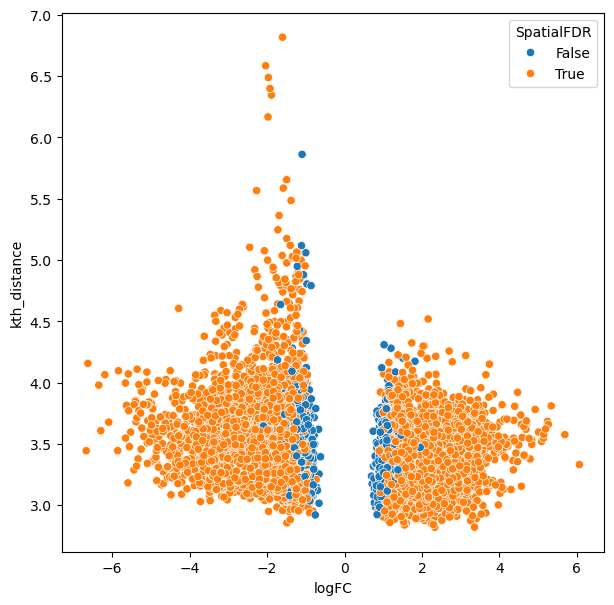

In [26]:
sns.scatterplot(
    data=sig_nhoods_cd8_age,
    x="logFC",
    y="kth_distance",
    hue=(sig_nhoods_cd8_age["SpatialFDR"] < 0.05)
)

In [27]:
pl_nhoods_cd8_age = (
    mdata_cd8_age["milo"].var.query("SpatialFDR < 0.1")
    .sort_values("logFC", ascending=False)
    .index[:6]
)

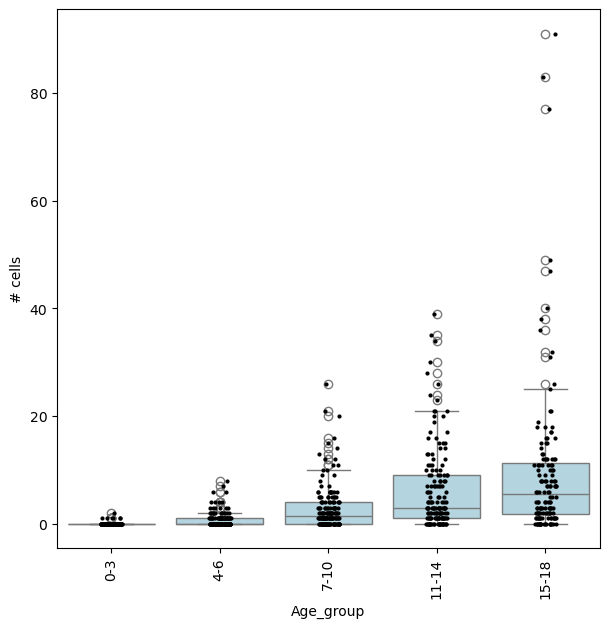

In [28]:
## Visualize cell counts by condition (x-axis) and individuals on all neighbourhoods
milo.plot_nhood_counts_by_cond(mdata_cd8_age, test_var="Age_group", subset_nhoods=pl_nhoods_cd8_age, log_counts=False)

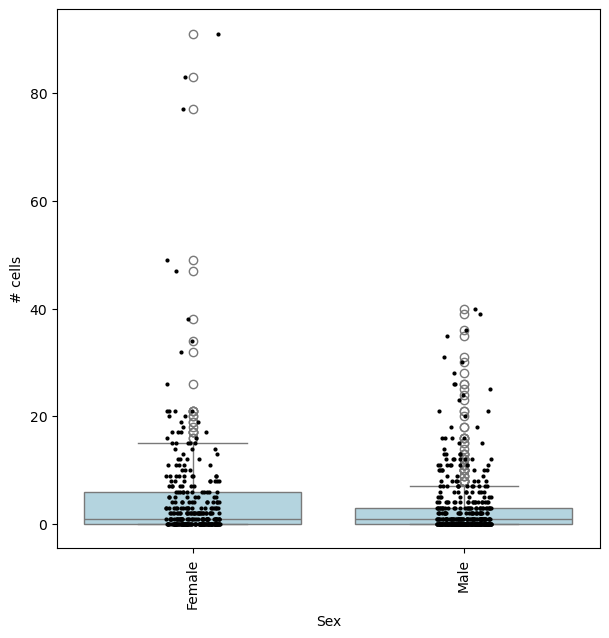

In [29]:
## Visualize cell counts by condition (x-axis) and individuals on all neighbourhoods
milo.plot_nhood_counts_by_cond(mdata_cd8_age, test_var="Sex", subset_nhoods=pl_nhoods_cd8_age, log_counts=False)

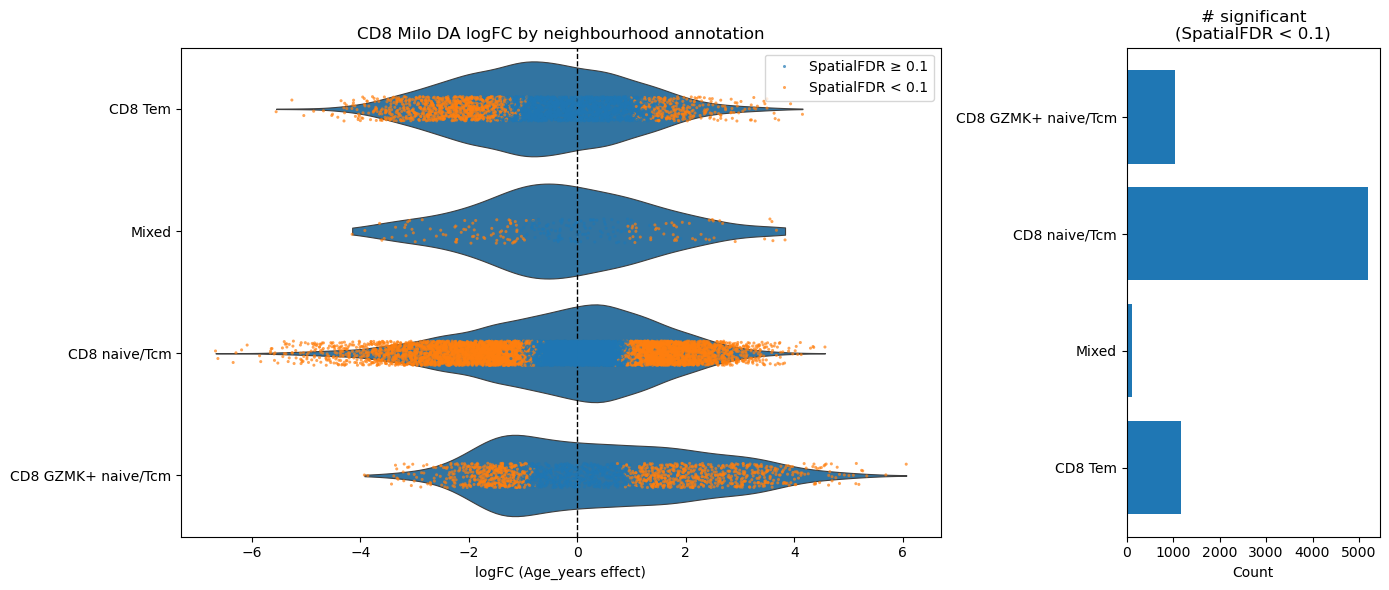

In [30]:
# full nhood results
df_cd8_age = mdata_cd8_age["milo"].var.copy()

# make sure the key columns exist
# df should already have: logFC, SpatialFDR, nhood_annotation
df_cd8_age["sig"] = df_cd8_age["SpatialFDR"] < 0.1

# (optional) order annotations by median logFC (most depleted on top)
order = (
    df_cd8_age.groupby("nhood_annotation")["logFC"]
      .median()
      .sort_values()  # depleted (more negative) first
      .index
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios":[3, 1]})

# ---- Panel A: logFC distribution by annotation ----
sns.violinplot(
    data=df_cd8_age, y="nhood_annotation", x="logFC",
    order=order, inner=None, cut=0, linewidth=0.8, ax=axes[0]
)
sns.stripplot(
    data=df_cd8_age, y="nhood_annotation", x="logFC",
    order=order, hue="sig", dodge=False, size=2.2,
    alpha=0.7, ax=axes[0]
)
axes[0].axvline(0, ls="--", c="k", lw=1)
axes[0].set_title("CD8 Milo DA logFC by neighbourhood annotation")
axes[0].set_xlabel("logFC (Age_years effect)")
axes[0].set_ylabel("")

# clean up legend (keep only one)
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:2], ["SpatialFDR ≥ 0.1", "SpatialFDR < 0.1"], title="", loc="upper right")

# ---- Panel B: counts of significant nhoods per annotation ----
sig_counts = (
    df_cd8_age[df_cd8_age["sig"]]
    .groupby("nhood_annotation")
    .size()
    .reindex(order, fill_value=0)
)

axes[1].barh(sig_counts.index, sig_counts.values)
axes[1].set_title("# significant\n(SpatialFDR < 0.1)")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()